<a href="https://colab.research.google.com/github/viictorsauraa/EML/blob/main/Entornos_Complejos/Qlearning_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q-Learning en Taxi-v3**

_Estudio del algoritmo de Diferencia Temporal (TD) Off-Policy_

Este notebook implementa y analiza el algoritmo **Q-Learning** sobre el entorno **Taxi-v3** de Gymnasium. A diferencia de los métodos de Monte Carlo, Q-Learning utiliza **bootstrapping**, permitiendo al agente aprender de sus estimaciones actuales sin esperar al final del episodio.

### **Q-Learning**
- **Aprendizaje Off-Policy**: El agente aprende directamente la política óptima $q_*$, independientemente de la política de comportamiento usada para explorar. La acción del target siempre es el $\max$ sobre todas las acciones posibles, no la acción que realmente se tomará después.
- **Diferencia Temporal (TD)**: Actualiza los valores $Q$ basándose en la recompensa inmediata y el máximo valor estimado del siguiente estado:
  $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)\right]$$
- **Eficiencia en Taxi-v3**: Al desacoplar la política de exploración del target de aprendizaje, Q-Learning converge hacia la política óptima independientemente de cuánto explore, aunque con mayor varianza en la recompensa durante el entrenamiento respecto a SARSA.


## **1. Preparación del Entorno**

La preparación consta de las siguientes partes:
- **Instalación de dependencias**: librería `gymnasium`.
- **Importación de librerías**: `numpy`, `matplotlib`, `tqdm`.
- **Creación del entorno Taxi-v3**: espacio de observación `Discrete(500)`, espacio de acciones `Discrete(6)`, `render_mode='rgb_array'` para visualización como imagen.
- **Importación de clases del repositorio**: `QLearningAgent`, funciones de visualización.

##### _________ **Código de la Instalación e Importación**
----

In [1]:
%%capture
#@title Instalamos gymnasium
!pip install gymnasium

In [2]:
#@title Importamos librerias
import sys
sys.path.insert(0, 'src')
import os
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

from agents import QLearningAgent
from plotting import plot, plot_lengths, show_greedy_episode_img, print_q_summary, plot_policy_taxi, plot_comparison, plot_lengths_comparison

In [3]:
# @title Semilla para reproducibilidad (sección 5.4 del PDF)
# Patrón recomendado: fijar la misma semilla en NumPy, Python y Gymnasium.
# Sin PyTorch porque este notebook es tabular (no usa redes neuronales).
SEED = 2024

# Fijar la semilla en NumPy
np.random.seed(SEED)
np.random.default_rng(SEED)

# Fijar la semilla en Python (evita variabilidad en hashing)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Semilla fija: SEED = {SEED}")

Semilla fija: SEED = 2024


Estados: 500, Acciones: 6
Recompensas: -1 por paso | +20 entrega exitosa | -10 acción ilegal

Estado inicial (seed=2024): 333
  Taxi: (3,1), Pasajero: B, Destino: G


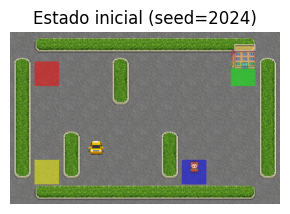

In [4]:
#@title Importamos el entorno Taxi-v3
env = gym.make('Taxi-v3', render_mode='rgb_array')
env.reset(seed=SEED)   # Fija la semilla del entorno (patrón sección 5.4 del PDF)

nS = env.observation_space.n  # 500
nA = env.action_space.n       # 6
print(f"Estados: {nS}, Acciones: {nA}")
print(f"Recompensas: -1 por paso | +20 entrega exitosa | -10 acción ilegal")
print()
# Estado inicial de ejemplo
obs, info = env.reset(seed=SEED)
print(f"Estado inicial (seed={SEED}): {obs}")
taxi_row, taxi_col, pass_loc, dest_idx = env.unwrapped.decode(obs)
locs = ['R', 'G', 'Y', 'B', 'en taxi']
print(f"  Taxi: ({taxi_row},{taxi_col}), Pasajero: {locs[pass_loc]}, Destino: {locs[dest_idx]}")

frame = env.render()
plt.figure(figsize=(3, 3))
plt.imshow(frame)
plt.axis('off')
plt.title(f"Estado inicial (seed={SEED})")
plt.tight_layout()
plt.savefig('estado_inicial.png', dpi=150, bbox_inches='tight')
plt.show()

## **2. Diseño del Agente**

El diseño del agente sigue el esquema de Gymnasium (sección 5.2): `__init__`, `get_action`, `update`, `stats`.

### **Política Epsilon-Greedy**
- El agente utiliza una política **$\epsilon$-soft** para garantizar la exploración continua del espacio de estados.
- Con probabilidad $1-\varepsilon$, selecciona la acción con el mayor valor $Q$ (explotación).
- Con probabilidad $\varepsilon$, selecciona una acción al azar (exploración).

### **Algoritmo Q-Learning**
- Implementado en la clase `QLearningAgent`, este algoritmo actualiza la tabla $Q$ en cada paso del entorno.
- A diferencia de SARSA,  Q-Learning es off-policy porque su target usa siempre `max_a Q(S', a)` independientemente de la acción que realmente tomará el agente. Recordemos:
 $$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t)\right]$$

In [5]:
# @title Constantes del entorno Taxi-v3
# Acciones del entorno Taxi-v3
SOUTH, NORTH, EAST, WEST, PICKUP, DROPOFF = 0, 1, 2, 3, 4, 5
ACTION_NAMES = {0: 'S↓', 1: 'N↑', 2: 'E→', 3: 'W←', 4: 'PU', 5: 'DO'}
# La política greedy se obtiene con agent.pi_star(seed=SEED, action_names=ACTION_NAMES)

## **3. Experimentación**

### **3.1 Representaciones Gráficas**

**Gráfica 1 — Recompensa media acumulada por episodio**: $f(t) = \frac{\sum_{i=1}^{t} R_i}{t}$. En Taxi-v3, esperamos que esta métrica pase de valores negativos al inicio a valores menos negativos y se estabilice; en configuraciones con poca exploración puede llegar a valores positivos (indicativo de entregas exitosas consistentes).

**Gráfica 2 — Longitud de los episodios**: Mide cuántos pasos tarda el taxi en completar la tarea.
1. **Inicio**: Los episodios suelen truncarse al límite de pasos (200) debido a la exploración ciega.
2. **Aprendizaje**: La longitud cae drásticamente a medida que el agente aprende a recoger al pasajero y evitar muros.
3. **Convergencia**: Se estabiliza cerca del rango esperado/empírico (aprox. 12-15 pasos).

**Función `show_greedy_episode`**: Permite observar el comportamiento final del taxista sin exploración, verificando si ha aprendido la secuencia lógica: Ir al pasajero $\rightarrow$ Pickup $\rightarrow$ Ir al destino $\rightarrow$ Dropoff.

**Función `plot_policy_taxi`**: Visualiza la política óptima aprendida, mostrando las acciones preferidas en cada estado. En Taxi-v3, esto revela las rutas óptimas hacia el pasajero y el destino, así como las acciones de pickup y dropoff.

### **3.2 Q-Learning en Taxi-v3**

Se entrenan **100 000 episodios** con $\varepsilon$ con decaimiento: $\varepsilon = \min(1.0,\ 1000/(t+1))$, igual que en SARSA y MC para poder comparar resultados con los mismos hiperparámetros.

El decaimiento es necesario porque:
- Al inicio, $\varepsilon$ alto favorece exploración amplia (el taxi descubre qué acciones son ilegales y aprende a evitarlas).
- Al final, $\varepsilon \to 0$ hace que la política de comportamiento se acerque a la greedy, reduciendo la longitud de los episodios.

A diferencia de SARSA, el decaimiento en Q-Learning solo afecta a la **política de comportamiento** (la exploración), no al target de aprendizaje, que siempre usa el máximo sobre acciones. Esto significa que Q-Learning puede aprender la política óptima incluso con alta exploración, aunque con mayor varianza en la recompensa durante el entrenamiento.

La semilla numpy fija (`SEED = 2024`) garantiza reproducibilidad.

In [6]:
# @title Aprendizaje off-policy (baseline)
agent_Q = QLearningAgent(env, epsilon=0.2, alpha=0.1, discount_factor=1.0, decay=True)
agent_Q.train(num_episodes=100000)
list_stats_Q, list_lengths_Q = agent_Q.stats()
Q_Q = agent_Q.q_values

 11%|█         | 10701/100000 [00:06<00:20, 4292.59it/s]

success: -103.9753, epsilon: 0.1000


 21%|██        | 20735/100000 [00:08<00:17, 4527.27it/s]

success: -49.8791, epsilon: 0.0500


 31%|███       | 30881/100000 [00:11<00:14, 4622.15it/s]

...

success: -7.4107, epsilon: 0.0125


 91%|█████████ | 90534/100000 [00:23<00:02, 4394.55it/s]

success: -5.7867, epsilon: 0.0111


100%|██████████| 100000/100000 [00:25<00:00, 3861.43it/s]

success: -4.4678, epsilon: 0.0100


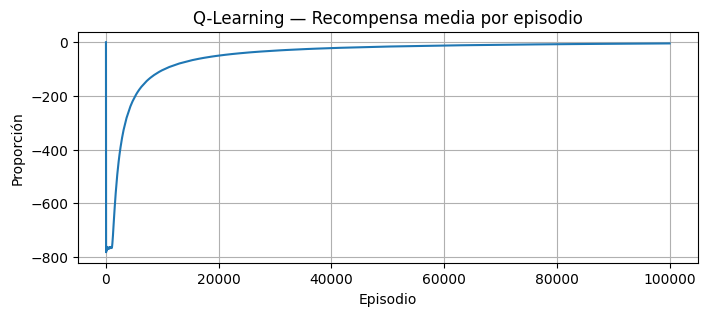

Recompensa media final: -4.47


In [7]:
#@title Recompensa media acumulada por episodio (off-policy)
plot(list_stats_Q, title='Q-Learning — Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada')
print(f'Recompensa media final: {list_stats_Q[-1]:.2f}')

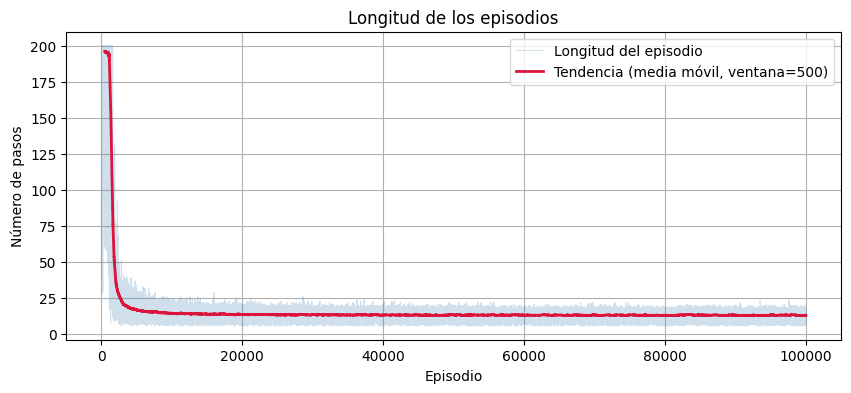

Longitud media final (últimos 1000 episodios): 13.06 pasos


In [8]:
#@title Longitud de episodios (off-policy)
plot_lengths(list_lengths_Q)
print(f'Longitud media final (últimos 1000 episodios): {np.mean(list_lengths_Q[-1000:]):.2f} pasos')

#### Resumen estadístico de la tabla Q aprendida. Con 500 estados y 6 acciones la tabla tiene 3000 entradas.
Se muestran estadísticas globales y algunos estados decodificados para verificar que el agente ha aprendido acciones coherentes.

In [9]:
# @title Resumen tabla Q — off-policy
print_q_summary(env, Q_Q, title="Off-Policy — Tabla Q")

--- Off-Policy — Tabla Q ---
  Entradas no nulas : 2400/3000 (80.0%)
  Max Q             : 20.000
  Min Q (no nulo)   : -18.135
  Q media (no nulo) : 0.692

  Muestra de estados:
  [  0] taxi=(0,0) pas=R       dst=R  -> mejor=S Q=[0. 0. 0. 0. 0. 0.]
  [124] taxi=(1,1) pas=G       dst=R  -> mejor=S Q=[  5.    -6.98  -1.61  -3.23 -12.33 -11.48]
  [249] taxi=(2,2) pas=Y       dst=G  -> mejor=W Q=[ 4.51  4.83  4.58  7.   -3.76 -3.37]
  [374] taxi=(3,3) pas=B       dst=Y  -> mejor=S Q=[11.    8.92  8.88  9.98  0.97  0.97]
  [499] taxi=(4,4) pas=en taxi dst=B  -> mejor=W Q=[15.49 15.67 15.59 19.    4.57  6.46]


Se muestra la política óptima greedy obtenida. `agent.pi_star(seed, action_names)` sigue `argmax Q[s]` desde el
estado inicial fijo (semilla SEED) y devuelve la secuencia de acciones en formato legible
(S↓ N↑ E→ W← PU DO). También se ejecuta `show_greedy_episode` para verificar visualmente
el resultado.

Política óptima obtenida (off-policy)
Acciones: E→ → N↑ → E→ → S↓ → S↓ → PU → N↑ → N↑ → E→ → N↑ → N↑ → DO



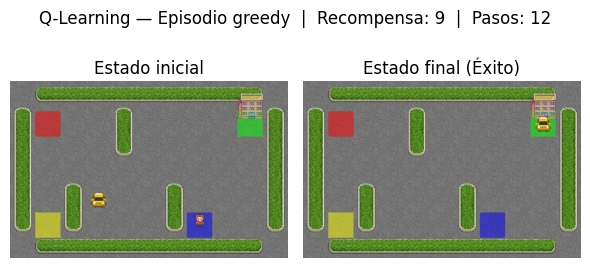

In [10]:
# @title Política final (off-policy)
pi, actions = agent_Q.pi_star(seed=SEED, action_names=ACTION_NAMES)
print("Política óptima obtenida (off-policy)")
print(f"Acciones: {actions}")
print()
show_greedy_episode_img(env, Q_Q, seed=SEED, title="Q-Learning — Episodio greedy")


Estado Inicial del Entorno (Pasajero: 3, Destino: 1):


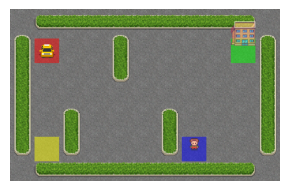

Mapa de Política (Mejor acción por celda):
-------------------------
| ↓ | ↓ | ↓ | ↓ | ↓ |
| ↓ | ↓ | ↓ | ↓ | ↓ |
| → | → | → | ↓ | ↓ |
| ↑ | → | ↑ | ↓ | ← |
| ↑ | → | ↑ | P | ← |
-------------------------


In [11]:
state, info = env.reset(seed=SEED)
# Extraer: taxi_row, taxi_col, pass_loc, dest_idx
_, _, pass_loc, dest_idx = env.unwrapped.decode(state)

plot_policy_taxi(env, agent_Q.q_values, passenger_loc=pass_loc, destination_idx=dest_idx)

### **3.3 Modificación de parámetros de Q-learning**

Los hiperparámetros en el algoritmo Q-Learning son fundamentales para equilibrar la explotación versus la exploración y cómo se gestionan las nuevas experiencias.

- La tasa de aprendizaje ($\alpha$) controla qué tan rápido el agente actualiza sus valores Q ante nueva información; un valor elevado puede acelerar la convergencia inicial pero generar inestabilidad, mientras que un valor bajo asegura una convergencia más suave y robusta.
- El parámetro épsilon ($\epsilon$) determina el grado de exploración. En Q-Learning, al ser off-policy, la exploración no afecta al target de aprendizaje (que siempre usa el $\max$), por lo que la varianza del retorno puede ser mayor que en SARSA con el mismo $\epsilon$.
- El decaimiento (decay) permite reducir gradualmente la exploración conforme avanza el entrenamiento, dejando que el agente explote la política óptima aprendida.
- El factor de descuento ($\gamma$) dicta la importancia de las recompensas futuras frente a las inmediatas; un $\gamma$ cercano a 1.0 es vital para que Q-Learning priorice completar la entrega final (recompensa de +20) a pesar de los costos negativos acumulados en cada paso del trayecto.

In [12]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=0.01, alpha=0.1, discount_factor=1.0, decay=False)
agent_Q.train(num_episodes=100000)
list_stats_Q_epsilon, list_lengths_Q_epsilon = agent_Q.stats()
Q_Q = agent_Q.q_values

 11%|█         | 10834/100000 [00:03<00:19, 4659.03it/s]

success: -3.7900, epsilon: 0.0100


 21%|██        | 20633/100000 [00:05<00:17, 4566.39it/s]

success: 1.8304, epsilon: 0.0100


 31%|███       | 30922/100000 [00:07<00:14, 4638.22it/s]

...

success: 6.0351, epsilon: 0.0100


 91%|█████████ | 90660/100000 [00:20<00:02, 4669.63it/s]

success: 6.1903, epsilon: 0.0100


100%|██████████| 100000/100000 [00:22<00:00, 4458.97it/s]

success: 6.3072, epsilon: 0.0100


In [13]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=0.2, alpha=0.5, discount_factor=1.0, decay=True)
agent_Q.train(num_episodes=100000)
list_stats_Q_alpha, list_lengths_Q_alpha = agent_Q.stats()
Q_Q = agent_Q.q_values

 11%|█         | 10570/100000 [00:06<00:21, 4167.42it/s]

success: -102.8104, epsilon: 0.1000


 21%|██        | 20820/100000 [00:08<00:17, 4488.64it/s]

success: -49.3231, epsilon: 0.0500


 31%|███       | 30925/100000 [00:11<00:14, 4614.34it/s]

...

success: -7.2849, epsilon: 0.0125


 90%|█████████ | 90471/100000 [00:24<00:02, 4660.89it/s]

success: -5.6610, epsilon: 0.0111


100%|██████████| 100000/100000 [00:26<00:00, 3818.25it/s]

success: -4.3522, epsilon: 0.0100


In [14]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=0.2, alpha=0.1, discount_factor=0.25, decay=True)
agent_Q.train(num_episodes=100000)
list_stats_Q_discount, list_lengths_Q_discount = agent_Q.stats()
Q_Q = agent_Q.q_values

 10%|█         | 10479/100000 [00:08<00:21, 4083.77it/s]

success: -128.1409, epsilon: 0.1000


 21%|██        | 20660/100000 [00:10<00:17, 4498.54it/s]

success: -62.0806, epsilon: 0.0500


 31%|███       | 30747/100000 [00:12<00:15, 4612.99it/s]

...

success: -10.4590, epsilon: 0.0125


 91%|█████████ | 90921/100000 [00:25<00:01, 4602.40it/s]

success: -8.4825, epsilon: 0.0111


100%|██████████| 100000/100000 [00:27<00:00, 3616.61it/s]

success: -6.8871, epsilon: 0.0100


In [15]:
# @title Aprendizaje off-policy
agent_Q = QLearningAgent(env, epsilon=0.2, alpha=0.1, discount_factor=0.05, decay=True)
agent_Q.train(num_episodes=100000)
list_stats_Q_bigdiscount, list_lengths_Q_bigdiscount = agent_Q.stats()
Q_Q = agent_Q.q_values

 10%|█         | 10087/100000 [00:15<01:53, 789.14it/s]

success: -217.9362, epsilon: 0.1000


 20%|██        | 20130/100000 [00:27<01:40, 796.89it/s]

success: -149.2652, epsilon: 0.0500


 30%|███       | 30114/100000 [00:39<01:33, 748.34it/s]

...

success: -92.2050, epsilon: 0.0125


 90%|█████████ | 90140/100000 [01:54<00:11, 830.65it/s]

success: -90.0728, epsilon: 0.0111


100%|██████████| 100000/100000 [02:06<00:00, 789.85it/s]

success: -88.1603, epsilon: 0.0100


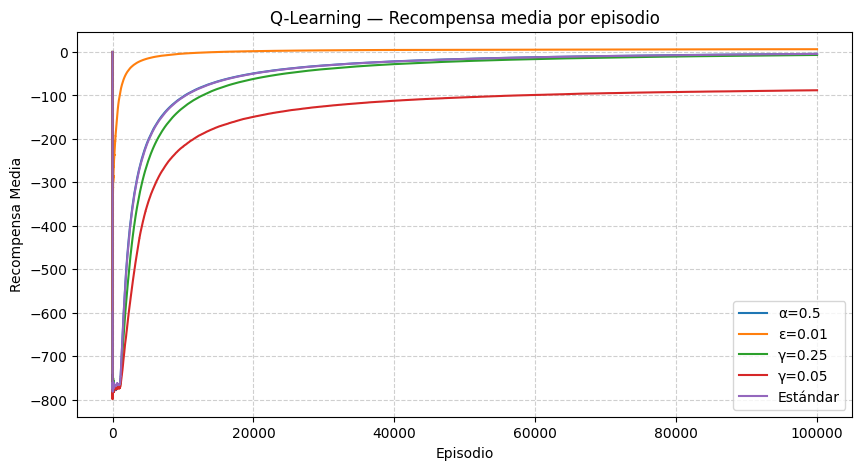

Recompensa media final de α=0.5: -4.35
Recompensa media final de ε=0.01: 6.31
Recompensa media final de γ=0.25: -6.89
Recompensa media final de γ=0.05: -88.16
Recompensa media final de Estándar: -4.47


In [16]:
#@title Recompensa media por episodio (off-policy)
lista_plots_recompensa = [list_stats_Q_alpha, list_stats_Q_epsilon, list_stats_Q_discount, list_stats_Q_bigdiscount, list_stats_Q]
labels = ['α=0.5', 'ε=0.01', 'γ=0.25', 'γ=0.05', 'Estándar']
plot_comparison(lista_plots_recompensa, title='Q-Learning — Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada', labels=labels)
for lista, label in zip(lista_plots_recompensa, labels):
    print(f'Recompensa media final de {label}: {lista[-1]:.2f}')

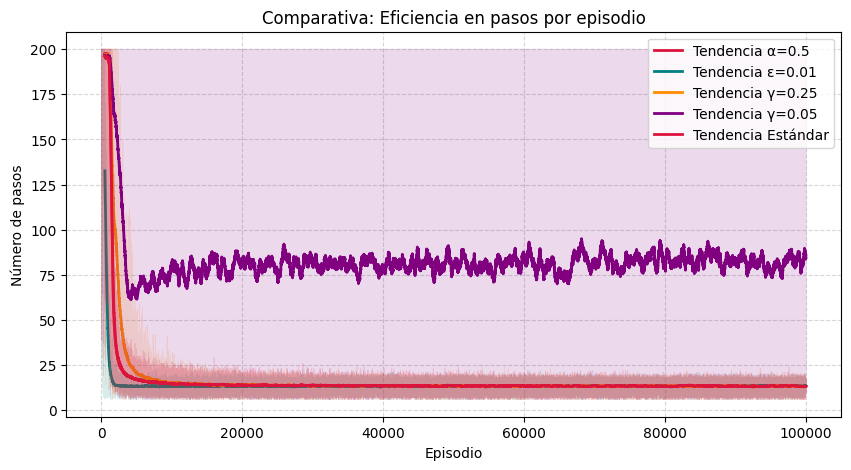

Longitud media final (últimos 1000 episodios) de α=0.5: 13.05 pasos
Longitud media final (últimos 1000 episodios) de ε=0.01: 13.38 pasos
Longitud media final (últimos 1000 episodios) de γ=0.25: 13.12 pasos
Longitud media final (últimos 1000 episodios) de γ=0.05: 82.97 pasos
Longitud media final (últimos 1000 episodios) de Estándar: 13.06 pasos


In [17]:
#@title Longitud de episodios (off-policy)
lista_plots_longitud = [list_lengths_Q_alpha, list_lengths_Q_epsilon, list_lengths_Q_discount, list_lengths_Q_bigdiscount, list_lengths_Q]
plot_lengths_comparison(lista_plots_longitud, labels=labels)
for lista, label in zip(lista_plots_longitud, labels):
    print(f'Longitud media final (últimos 1000 episodios) de {label}: {np.mean(lista[-1000:]):.2f} pasos')

### **3.3.1 Análisis de los hiperparámetros**

### **3.3.1 Análisis de Resultados y Comparación de Configuraciones**

En esta sección se evalúa el impacto de los hiperparámetros en el aprendizaje de Q-Learning. Se han definido tres configuraciones específicas (más la original) para observar cómo afectan al desarrollo del entrenamiento en el entorno Taxi-v3:

1. **Configuración 1 ($\epsilon=0.01$)** sin decaimiento: Minimiza la exploración desde el inicio. En Q-Learning esto es especialmente efectivo porque, al ser off-policy, el agente puede explotar la política óptima estimada desde los primeros episodios sin que ello sesgue el target de aprendizaje.
2. **Configuración 2 ($\alpha=0.5$)**: Dobla la tasa de aprendizaje, permitiendo actualizaciones más rápidas. Sin embargo, en este experimento no muestra una mejora claramente superior frente a la configuración estándar.
3. **Configuración 3 ($\gamma=0.25$)**: Reduce la importancia de las recompensas futuras. El agente converge, pero a una política peor, porque descuenta fuertemente la recompensa de entrega (+20) que llega al final de la secuencia.
4. **Configuración 4 ($\gamma=0.05$)**: Descuento extremo. La recompensa futura queda tan fuertemente descontada que su propagación hacia estados anteriores resulta insuficiente para aprender una política efectiva.

#### **Interpretación de las Gráficas**

**Recompensa Media Acumulada**:
- **$\epsilon=0.01$** es la configuración con mejor rendimiento global: alcanza las recompensas medias más altas y converge rápidamente. Al reducir casi por completo la exploración desde el inicio, el agente explota antes las estimaciones de valor aprendidas.
- **$\alpha=0.5$** muestra un rendimiento competitivo, aunque no mejora de forma claramente superior a la configuración estándar. Una tasa de aprendizaje mayor permite actualizaciones más rápidas, pero en este entorno su ventaja final es limitada.
- **Estándar** converge de forma estable, aunque más lentamente en las primeras fases debido a la exploración inicial elevada ($\epsilon \approx 1$ durante los primeros 1000 episodios).
- **$\gamma=0.25$** converge a una recompensa media inferior a las configuraciones anteriores: reducir el peso de las recompensas futuras perjudica la calidad de la política aprendida.
- **$\gamma=0.05$** no logra un aprendizaje efectivo: la recompensa media se estabiliza en valores muy negativos durante todo el entrenamiento.

**Longitud de los Episodios**:
- Todas las configuraciones excepto $\gamma=0.05$ convergen a episodios cortos (~10-15 pasos), lo que indica que aprenden políticas eficientes para completar la tarea.
- Entre las configuraciones que sí aprenden, las diferencias finales en número de pasos son pequeñas y no permiten afirmar con rotundidad que una descubra rutas claramente mejores que las otras.
- $\gamma=0.05$ mantiene episodios largos (~80 pasos) con alta varianza durante todo el entrenamiento, confirmando que no aprende una política adecuada.

## **4. Análisis y Conclusiones**

### **4.1 Comportamiento de Q-Learning en Taxi-v3**

Q-Learning converge a una política altamente eficiente y compatible con el comportamiento esperado de una política óptima en Taxi-v3, como sugiere el episodio greedy final: el taxi realiza la secuencia correcta (ir al pasajero → pickup → ir al destino → dropoff) sin errores ni acciones ilegales.

La tabla Q resultante presenta 2400/3000 entradas no nulas (80%), con un valor máximo de Q = 20 y una media de Q = 0.692 para entradas no nulas. Que el valor máximo alcance 20 es consistente con haber aprendido correctamente acciones terminales asociadas a la entrega exitosa. El valor medio modesto refleja que los estados intermedios del trayecto tienen valores bajos, ya que cada paso cuesta -1 y la recompensa positiva solo llega al final.

Al ser off-policy, Q-Learning estima el valor de la política codiciosa respecto a Q, separando aprendizaje y comportamiento exploratorio. Bajo condiciones adecuadas de exploración y actualización, esto favorece la convergencia hacia $q_*$.

### **4.2 Comparativa Q-Learning vs SARSA vs Monte Carlo On y Off Policy**

La comparativa entre los cuatro algoritmos con los mismos hiperparámetros revela el efecto de cada dimensión del diseño 2×2:

**TD vs MC (dimensión dominante)**: Los métodos de Diferencia Temporal (Q-Learning y SARSA) superan ampliamente a los métodos Monte Carlo en ambas métricas. Los métodos Monte Carlo actualizan a partir del retorno completo del episodio, por lo que su aprendizaje se retrasa especialmente cuando los episodios iniciales son largos — como ocurre en Taxi-v3, donde el taxi vaga hasta el límite de 200 pasos. Q-Learning y SARSA aprenden en cada paso, lo que les permite converger en los primeros miles de episodios.

**On-policy vs Off-policy (efecto asimétrico)**: El impacto de esta dimensión depende del tipo de estimación:
- **En TD**: Q-Learning y SARSA son casi indistinguibles en las gráficas. La diferencia entre on-policy y off-policy dentro de los métodos TD es pequeña en este entorno.
- **En MC**: MC Off-Policy supera claramente a MC On-Policy. MC Off-Policy puede estimar la política objetivo a partir de episodios generados por una política de comportamiento distinta mediante muestreo por importancia, lo que le permite acabar convergiendo mejor que MC On-Policy, aunque con menor eficiencia que los métodos TD.

### **4.3 Conclusiones**

- La dimensión **TD vs MC** es la que más determina el rendimiento en Taxi-v3: el bootstrapping es imprescindible en entornos donde los episodios iniciales son muy largos.
- La dimensión **on/off-policy** no tiene un efecto uniforme: es decisiva para MC (MC Off-Policy >> MC On-Policy) pero casi irrelevante para TD (Q-Learning ≈ SARSA). Las dos dimensiones del diseño 2×2 **no son independientes ni aditivas** — su interacción es el hallazgo más relevante de esta comparativa.
- Q-Learning es el algoritmo con mejor rendimiento global en este experimento, aunque las gráficas sugieren que gran parte de esa ventaja proviene del uso de bootstrapping más que del carácter off-policy en sí.

## **5. Comparativa: Q-Learning vs SARSA vs MC On-Policy vs MC Off-Policy**

Los cuatro algoritmos se entrenan con los **mismos hiperparámetros** (`ε=0.2`, `α=0.1`, `γ=1.0`, decay, 100 000 episodios, SEED=2024) para aislar el efecto del algoritmo y no de la configuración. El diseño cubre el espacio completo {on/off-policy} × {TD/MC}:

| | TD (bootstrapping) | MC (retorno completo) |
|---|---|---|
| **Off-policy** | Q-Learning | MC Off-Policy |
| **On-policy** | SARSA | MC On-Policy |

**Pregunta experimental:** ¿Cuál de las dos dimensiones (tipo de política o tipo de estimación) tiene mayor impacto en la velocidad y estabilidad de convergencia en Taxi-v3?

In [18]:
# @title Entrenamiento comparativo — mismos hiperparámetros para los 4 algoritmos
from agents import SARSAAgent, MonteCarloOnPolicyAgent, MonteCarloOffPolicyAgent

N_EPISODES = 100000

# Q-Learning ya entrenado en sección 3.2 con los mismos hiperparámetros
stats_cmp_Q, lengths_cmp_Q = list_stats_Q, list_lengths_Q

print("Entrenando SARSA...")
np.random.seed(SEED)
agent_cmp_S = SARSAAgent(env, epsilon=0.2, alpha=0.1, discount_factor=1.0, decay=True)
agent_cmp_S.train(num_episodes=N_EPISODES)
stats_cmp_S, lengths_cmp_S = agent_cmp_S.stats()

print("\nEntrenando Monte Carlo On-Policy...")
np.random.seed(SEED)
agent_cmp_MC = MonteCarloOnPolicyAgent(env, epsilon=0.2, decay=True, discount_factor=1.0)
agent_cmp_MC.train(num_episodes=N_EPISODES)
stats_cmp_MC, lengths_cmp_MC = agent_cmp_MC.stats()

print("\nEntrenando Monte Carlo Off-Policy...")
np.random.seed(SEED)
agent_cmp_MC_off = MonteCarloOffPolicyAgent(env, epsilon=0.2, decay=True, discount_factor=1.0)
agent_cmp_MC_off.train(num_episodes=N_EPISODES)
stats_cmp_MC_off, lengths_cmp_MC_off = agent_cmp_MC_off.stats()

print("\nEntrenamiento completado.")

Entrenando SARSA...


 11%|█         | 10752/100000 [00:06<00:21, 4216.51it/s]

success: -112.7662, epsilon: 0.1000


 21%|██        | 20575/100000 [00:09<00:17, 4459.18it/s]

success: -54.2963, epsilon: 0.0500


...

success: -29.6167, epsilon: 0.0125


 90%|█████████ | 90471/100000 [00:36<00:02, 4239.88it/s]

success: -25.5641, epsilon: 0.0111


100%|██████████| 100000/100000 [00:38<00:00, 2614.87it/s]

success: -22.3160, epsilon: 0.0100

Entrenamiento completado.


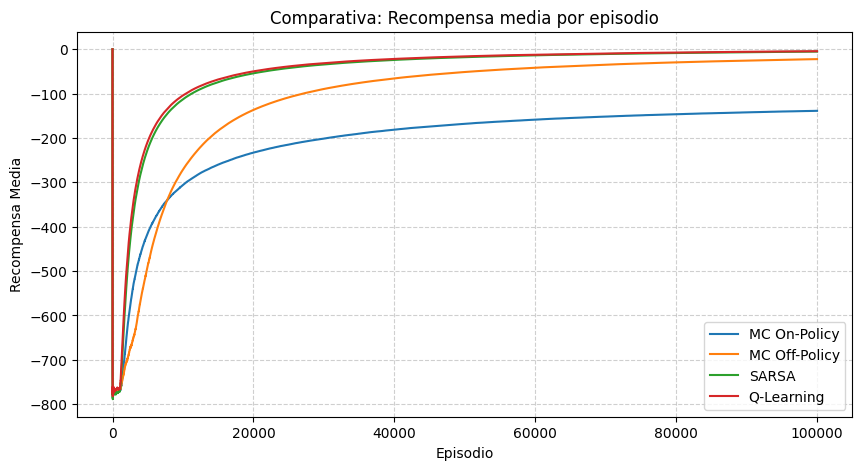

MC On-Policy         — Recompensa media final: -138.82
MC Off-Policy        — Recompensa media final: -22.32
SARSA                — Recompensa media final: -5.34
Q-Learning           — Recompensa media final: -4.47


In [19]:
# @title Comparativa: Recompensa media por episodio
LABELS = ['MC On-Policy', 'MC Off-Policy', 'SARSA', 'Q-Learning']

plot_comparison(
    [stats_cmp_MC, stats_cmp_MC_off, stats_cmp_S, stats_cmp_Q],
    labels=LABELS,
    title='Comparativa: Recompensa media acumulada por episodio', ylabel='Recompensa media acumulada'
)

for stats, label in zip([stats_cmp_MC, stats_cmp_MC_off, stats_cmp_S, stats_cmp_Q], LABELS):
    print(f'{label:20s} — Recompensa media final: {stats[-1]:.2f}')

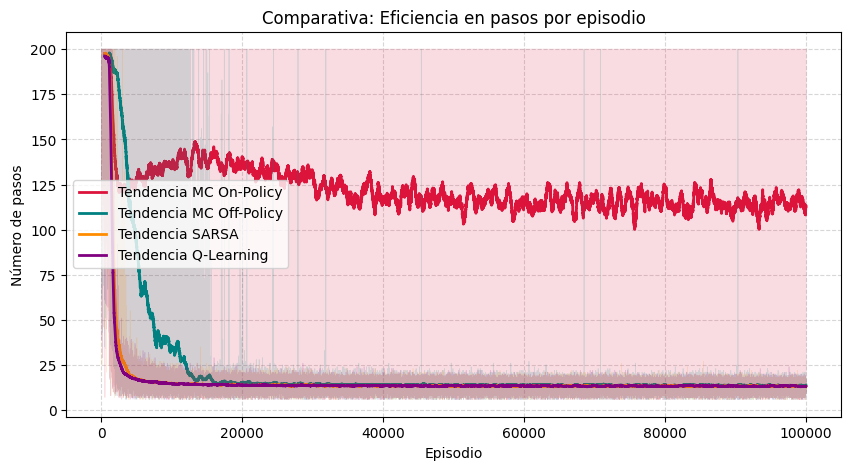

MC On-Policy         — Longitud media final (últimos 1000 ep.): 113.73 pasos
MC Off-Policy        — Longitud media final (últimos 1000 ep.): 13.69 pasos
SARSA                — Longitud media final (últimos 1000 ep.): 13.04 pasos
Q-Learning           — Longitud media final (últimos 1000 ep.): 13.06 pasos


In [20]:
# @title Comparativa: Longitud de episodios (velocidad de convergencia)
plot_lengths_comparison(
    [lengths_cmp_MC, lengths_cmp_MC_off, lengths_cmp_S, lengths_cmp_Q],
    labels=LABELS
)

for lengths, label in zip([lengths_cmp_MC, lengths_cmp_MC_off, lengths_cmp_S, lengths_cmp_Q], LABELS):
    print(f'{label:20s} — Longitud media final (últimos 1000 ep.): {np.mean(lengths[-1000:]):.2f} pasos')